# 🤖 NLP Phase 4 — Deep Learning for NLP
### RNN | LSTM | Sentiment Analysis
**Super simple. Every line explained. No advanced stuff.**

---

## 🤔 What did we do in Phase 1, 2, 3?

| Phase | What we did |
|-------|------------|
| Phase 1 | Cleaned text (remove noise, tokenize, lemmatize) |
| Phase 2 | Converted text to numbers (BoW, TF-IDF) |
| Phase 3 | Word Embeddings — words as meaningful numbers |

In all of those, we used **simple ML models** (Naive Bayes, Logistic Regression).

---

## 💡 What is different in Phase 4?

Simple ML models have one big problem:
> They look at words **independently** — they don't understand ORDER.

For example:
```
"The movie was not good"   → simple model sees: movie, good, not
"The movie was good"       → simple model sees: movie, good
```
The model sees `good` in BOTH and might call both positive!
It missed the word `not` changes everything.

**Deep Learning models read text like humans — word by word, in order.**
They remember what came before. That is the key difference.

---

## 🗺️ What we learn in Phase 4

| Step | Topic | Simple explanation |
|------|-------|-------------------|
| 1 | **RNN idea** | A model that reads text word by word |
| 2 | **LSTM idea** | A smarter RNN that has memory |
| 3 | **Build LSTM model** | Code a sentiment classifier step by step |
| 4 | **Train the model** | Feed data, let it learn |
| 5 | **Test on new text** | See if it works on real sentences |

---
**How to use:** Press **Shift + Enter** on each cell. Read the 📖 note above every cell first!

---
# 📦 CELL 1 — Install and Import
📖 **TensorFlow** is the deep learning library made by Google.
It has everything we need to build RNN and LSTM models.
It is already installed in Google Colab — we just import it!

In [1]:
# TensorFlow is Google's deep learning library
# It is already available in Google Colab — no installation needed!
import tensorflow as tf

# From tensorflow.keras we import the tools to build neural networks
# keras is the easy-to-use part of TensorFlow
from tensorflow.keras.models     import Sequential
# Sequential = a model where layers are stacked one after another

from tensorflow.keras.layers     import Embedding
# Embedding = converts word numbers into word vectors automatically

from tensorflow.keras.layers     import LSTM
# LSTM = Long Short-Term Memory — reads text and remembers context

from tensorflow.keras.layers     import Dense
# Dense = a regular fully-connected layer for final prediction

from tensorflow.keras.layers     import Dropout
# Dropout = randomly turns off some neurons to prevent overfitting

from tensorflow.keras.preprocessing.text     import Tokenizer
# Tokenizer = converts words to numbers (each word gets a unique ID)

from tensorflow.keras.preprocessing.sequence import pad_sequences
# pad_sequences = makes all sentences the same length by adding zeros

# numpy for math operations
import numpy as np

# matplotlib for drawing training charts
import matplotlib.pyplot as plt

# random for shuffling data
import random

# Set seeds so results are same every time we run
# Without this, results change slightly every run
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("✅ All imports done!")
print(f"TensorFlow version: {tf.__version__}")

✅ All imports done!
TensorFlow version: 2.19.0


---
---
# 📌 STEP 1 — What is an RNN? (The Idea)

📖 **RNN = Recurrent Neural Network**

Normal neural networks read ALL words at once.
RNN reads text **one word at a time**, left to right — just like you are reading this sentence right now!

📖 **The key feature: Memory**

After reading each word, RNN keeps a **memory** (called hidden state).
This memory carries information from previous words to the next word.

```
Sentence: "The movie was not good"

Step 1: Read 'The'  → memory = [info about 'The']
Step 2: Read 'movie'→ memory = [info about 'The movie']
Step 3: Read 'was'  → memory = [info about 'The movie was']
Step 4: Read 'not'  → memory = [info about 'The movie was not']
Step 5: Read 'good' → memory = [info about 'The movie was not good']
                                                    ↓
                              Final answer: NEGATIVE (because of 'not')
```

📖 **Problem with RNN:**
RNN forgets things that happened far back in the sentence.
For very long sentences, it forgets the beginning by the time it reaches the end.
This is called the **vanishing gradient problem**.

**Solution → LSTM** (our next topic!)

In [2]:
# ---- Visualize the RNN idea with a simple example ----
# We are NOT building a real RNN here — just showing the concept with print statements

sentence = "The movie was not good"

# Split the sentence into words
words = sentence.split()

# Pretend this is the memory — starts empty
memory = "(empty)"

print("How RNN reads a sentence — word by word:")
print()
print(f"Sentence: '{sentence}'")
print()

# Loop through each word — this shows how RNN reads one word at a time
for i, word in enumerate(words):

    # After reading this word, update the memory
    # In a real RNN, this update uses math (matrix multiplication)
    # Here we just show it simply as text
    memory = ' '.join(words[:i+1])   # Memory = all words seen so far

    print(f"Step {i+1}: Read '{word}'")
    print(f"         Memory now = '{memory}'")
    print()

print("Final memory contains info about the FULL sentence!")
print("The model uses this final memory to make a prediction.")

How RNN reads a sentence — word by word:

Sentence: 'The movie was not good'

Step 1: Read 'The'
         Memory now = 'The'

Step 2: Read 'movie'
         Memory now = 'The movie'

Step 3: Read 'was'
         Memory now = 'The movie was'

Step 4: Read 'not'
         Memory now = 'The movie was not'

Step 5: Read 'good'
         Memory now = 'The movie was not good'

Final memory contains info about the FULL sentence!
The model uses this final memory to make a prediction.


---
---
# 📌 STEP 2 — What is LSTM? (The Idea)

📖 **LSTM = Long Short-Term Memory**

LSTM was invented in **1997** to fix the RNN forgetting problem.
LSTM has a smarter memory system with **3 gates** — think of them as doors:

```
🚪 FORGET GATE  → "Should I forget something from memory?"
                   Example: After reading a new topic, forget the old topic

🚪 INPUT GATE   → "Should I add this new word to memory?"
                   Example: 'not' is important — add it!
                   Example: 'the' is not important — maybe skip it

🚪 OUTPUT GATE  → "What should I output from memory right now?"
                   Example: Output relevant info for the current prediction
```

📖 **Simple analogy:**
Think of LSTM like a student reading a textbook:
- They **forget** irrelevant details (yesterday's lunch)
- They **remember** important facts (key formulas)
- They **use** only the relevant memory when answering a question

📖 **LSTM vs RNN:**

| | RNN | LSTM |
|--|-----|------|
| Memory | Simple, forgets easily | Smart gates, remembers longer |
| Long sentences | Struggles | Handles well |
| Speed | Faster | Slightly slower |
| Use today | Rarely | Very common |

**We will build an LSTM model for Sentiment Analysis — positive or negative review!**

---
---
# 📌 STEP 3 — Prepare the Data

📖 We will build a **Sentiment Classifier**.
Given a movie review, the model will say:
- **1 = Positive** (good review)
- **0 = Negative** (bad review)

📖 We create our own small dataset here.
In a real project you would use a large dataset like IMDB (50,000 reviews).

In [3]:
# ---- Our dataset: movie reviews with labels ----
# 1 = Positive review
# 0 = Negative review

reviews = [
    # Positive reviews
    "this movie was absolutely amazing and wonderful",
    "i loved every minute of this film it was great",
    "fantastic story with brilliant acting and direction",
    "one of the best movies i have ever seen in my life",
    "truly an outstanding film with superb performances",
    "the movie was so good i watched it twice already",
    "excellent cinematography and a gripping storyline",
    "a masterpiece of cinema that everyone should watch",
    "the acting was phenomenal and the story was touching",
    "loved this movie from beginning to end absolutely brilliant",
    "this film moved me deeply it was incredibly emotional",
    "the best film of the year without any doubt at all",
    "amazing movie with great characters and beautiful music",
    "i enjoyed this film so much it made me very happy",
    "wonderful experience watching this incredible movie tonight",

    # Negative reviews
    "this movie was absolutely terrible and boring to watch",
    "i hated this film it was a complete waste of time",
    "worst movie i have ever seen in my entire life",
    "terrible acting and a very predictable boring story",
    "i fell asleep during this dull and disappointing film",
    "the movie was so bad i left the cinema early tonight",
    "awful direction and a pointless story with no ending",
    "do not waste your money on this horrible film at all",
    "the acting was very poor and the plot made no sense",
    "hated this movie from beginning to end it was rubbish",
    "this film was painfully slow and incredibly boring overall",
    "the worst film of the year by a very long way",
    "bad movie with weak characters and annoying music throughout",
    "i disliked this film so much it made me very angry",
    "disappointing experience watching this dreadful movie tonight",
]

# Labels: 1 for each positive review, 0 for each negative review
# We have 15 positive and 15 negative reviews
labels = [1]*15 + [0]*15
# [1]*15 creates a list of fifteen 1s: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
# [0]*15 creates a list of fifteen 0s: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# The + joins both lists together

print(f"Total reviews : {len(reviews)}")
print(f"Positive (1)  : {labels.count(1)}")
print(f"Negative (0)  : {labels.count(0)}")
print()
print("Sample positive review:")
print(f"  '{reviews[0]}'")
print()
print("Sample negative review:")
print(f"  '{reviews[15]}'")

Total reviews : 30
Positive (1)  : 15
Negative (0)  : 15

Sample positive review:
  'this movie was absolutely amazing and wonderful'

Sample negative review:
  'this movie was absolutely terrible and boring to watch'


In [4]:
# ---- Convert words to numbers ----
# Neural networks only understand numbers, not words
# We assign each unique word a unique number (an ID)
# Example: 'movie'=1, 'good'=2, 'bad'=3, 'the'=4, ...

# Step 1: Create a Tokenizer object
# num_words=500 means: keep only the 500 most common words
# (ignores very rare words to save memory)
tokenizer = Tokenizer(num_words=500)

# Step 2: fit_on_texts() — reads all reviews and builds the vocabulary
# It counts every word and assigns each one a number
tokenizer.fit_on_texts(reviews)

# Step 3: texts_to_sequences() — converts each review into a list of numbers
# Example: 'this movie was good' → [4, 1, 7, 2]
sequences = tokenizer.texts_to_sequences(reviews)

# Show the vocabulary (first 15 words)
# word_index is a dictionary: {word: number}
word_index = tokenizer.word_index
print("Vocabulary (word → number):")
# items() gives us (word, number) pairs
# list()[:15] takes only the first 15
for word, num in list(word_index.items())[:15]:
    print(f"  '{word}' = {num}")

print(f"\nTotal unique words found: {len(word_index)}")
print()

# Show what a review looks like after conversion
print(f"Original  : '{reviews[0]}'")
print(f"As numbers: {sequences[0]}")

Vocabulary (word → number):
  'this' = 1
  'was' = 2
  'and' = 3
  'the' = 4
  'movie' = 5
  'film' = 6
  'i' = 7
  'it' = 8
  'of' = 9
  'a' = 10
  'with' = 11
  'very' = 12
  'story' = 13
  'acting' = 14
  'so' = 15

Total unique words found: 124

Original  : 'this movie was absolutely amazing and wonderful'
As numbers: [1, 5, 2, 16, 22, 3, 23]


In [5]:
# ---- Make all sequences the same length ----
# Problem: Each review has a different number of words
# Review 1 might have 8 words, Review 2 might have 12 words
# Neural networks need ALL inputs to be the SAME size

# Solution: PADDING
# We set a maximum length and:
#   - Short reviews get 0s added at the start (padding)
#   - Long reviews get cut at the end (truncation)

MAX_LENGTH = 20
# MAX_LENGTH = 20 means every review will become 20 numbers long

# pad_sequences() does the padding/truncating for us
# padding='pre'   means: add zeros at the START of short sequences
# truncating='pre' means: cut from the START if too long
# maxlen=MAX_LENGTH means: target length is 20
X = pad_sequences(
    sequences,
    maxlen    = MAX_LENGTH,
    padding   = 'pre',
    truncating = 'pre'
)

# Convert labels list to numpy array
# Neural networks work with numpy arrays, not Python lists
y = np.array(labels)

print(f"Shape of X (reviews as numbers): {X.shape}")
print(f"  → {X.shape[0]} reviews, each with {X.shape[1]} numbers")
print(f"Shape of y (labels): {y.shape}")
print()

# Show the first review after padding
print(f"Review 1 original  : '{reviews[0]}'")
print(f"Review 1 as numbers: {X[0]}")
print()
print("Notice: zeros at the start are the padding (the review was shorter than 20 words)")

Shape of X (reviews as numbers): (30, 20)
  → 30 reviews, each with 20 numbers
Shape of y (labels): (30,)

Review 1 original  : 'this movie was absolutely amazing and wonderful'
Review 1 as numbers: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  1  5  2 16 22  3 23]

Notice: zeros at the start are the padding (the review was shorter than 20 words)


In [6]:
# ---- Split into Training and Testing data ----
# We train the model on some reviews, then test on reviews it has never seen
# This tells us if the model actually learned or just memorized

# We split manually here — 80% train, 20% test
# Total 30 reviews → 24 for training, 6 for testing

# Total number of reviews
total = len(X)

# Calculate split point: 80% of total
# int() converts the result to a whole number (no decimal)
split = int(total * 0.8)

# Training data: reviews from index 0 to split
# X[:split] means: take all rows from the start up to (but not including) split
X_train = X[:split]
y_train = y[:split]

# Testing data: reviews from split to the end
# X[split:] means: take all rows from split to the end
X_test = X[split:]
y_test = y[split:]

print(f"Total reviews   : {total}")
print(f"Training reviews: {len(X_train)} (80%)")
print(f"Testing reviews : {len(X_test)}  (20%)")

Total reviews   : 30
Training reviews: 24 (80%)
Testing reviews : 6  (20%)


---
---
# 📌 STEP 4 — Build the LSTM Model

📖 Our model has **4 layers** stacked on top of each other:

```
INPUT  →  [word numbers like 4, 1, 7, 2 ...]
           ↓
Layer 1:  Embedding  → converts word numbers into word vectors
           ↓
Layer 2:  LSTM       → reads vectors one by one, builds memory
           ↓
Layer 3:  Dropout    → randomly turns off neurons to prevent overfitting
           ↓
Layer 4:  Dense      → takes memory, outputs ONE number between 0 and 1
           ↓
OUTPUT →  0.8 → Positive!   (above 0.5 = positive)
          0.2 → Negative!   (below 0.5 = negative)
```

📖 **What each layer does simply:**
- **Embedding** = Like a lookup table. Give it word number 5, it gives back a vector [0.2, -0.1, 0.8...]
- **LSTM** = Reads the vectors in order, builds a memory of the whole sentence
- **Dropout** = During training, randomly turns off 50% of neurons. Forces model to not rely on any one neuron — makes it stronger
- **Dense** = Takes the LSTM memory and squashes it to ONE number between 0 and 1 (the prediction)

In [7]:
# ---- Build the LSTM model ----

# How many unique words exist in our vocabulary
# We add 1 because word IDs start from 1 (0 is reserved for padding)
VOCAB_SIZE = len(tokenizer.word_index) + 1

# How many numbers represent each word in the Embedding layer
EMBED_DIM = 16
# EMBED_DIM = 16 means each word gets a vector of 16 numbers
# (Phase 3 used 50-300, we use 16 here because our dataset is tiny)

# Sequential means: layers stacked one after another in a sequence
model = Sequential([

    # LAYER 1: Embedding
    # input_dim    = vocabulary size (how many unique words)
    # output_dim   = how many numbers per word vector
    # input_length = how many words in each review (our MAX_LENGTH)
    Embedding(
        input_dim    = VOCAB_SIZE,
        output_dim   = EMBED_DIM,
        input_length = MAX_LENGTH
    ),

    # LAYER 2: LSTM
    # 32 = number of memory units in the LSTM
    # More units = can remember more complex patterns
    # 32 is enough for our small dataset
    LSTM(32),

    # LAYER 3: Dropout
    # 0.5 means: randomly turn off 50% of neurons during training
    # This prevents the model from memorizing the training data
    # (called overfitting — when model does great on training but fails on new data)
    Dropout(0.5),

    # LAYER 4: Dense (output layer)
    # 1 = output ONE single number
    # activation='sigmoid' squashes the output to be between 0 and 1
    # Output close to 1 = positive, close to 0 = negative
    Dense(1, activation='sigmoid'),

])

# ---- Compile the model ----
# Compiling sets up HOW the model will learn
model.compile(
    optimizer = 'adam',               # Adam = a smart algorithm that adjusts learning speed
    loss      = 'binary_crossentropy', # Loss function for yes/no (binary) problems
    metrics   = ['accuracy']           # We want to track accuracy during training
)

# Print a summary of our model — shows all layers and their sizes
print("Model Summary:")
model.summary()

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
---
# 📌 STEP 5 — Train the Model

📖 **What happens during training?**

```
1. Model reads a review (as numbers)
2. Model makes a guess: 0.3 (thinks negative)
3. We compare guess with real answer: 1 (actually positive)
4. We calculate the error (called loss): it was wrong!
5. Model adjusts its numbers slightly to be less wrong next time
6. Repeat for ALL reviews — this is ONE epoch
7. Do this for many epochs until the model is accurate
```

📖 **What is an epoch?**
One epoch = the model has seen ALL training reviews once.
We train for multiple epochs so the model sees the data many times and keeps improving.

📖 **What is batch size?**
Instead of updating after every single review, we update after every `batch_size` reviews.
Batch size = 8 means: look at 8 reviews, calculate average error, then update.

In [8]:
# ---- Train the LSTM model ----

# model.fit() starts the training process
history = model.fit(

    X_train,          # Training reviews (as padded number sequences)
    y_train,          # Training labels (0 or 1)

    epochs     = 30,  # Train for 30 rounds (epochs)
                      # Each epoch = model sees all training data once

    batch_size = 4,   # Process 4 reviews at a time before updating
                      # Smaller batch = more updates = slower but can be more accurate

    validation_data = (X_test, y_test),
    # validation_data = test set to check performance on unseen data after each epoch
    # This lets us see if the model is improving on new data too

    verbose = 1,      # verbose=1 means: print progress after each epoch
                      # verbose=0 = silent, verbose=2 = more detail
)

# history stores the accuracy and loss for every epoch
# We will use it to draw a chart below
print()
print("✅ Training complete!")

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5833 - loss: 0.6919 - val_accuracy: 0.0000e+00 - val_loss: 0.7050
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6870 - val_accuracy: 0.0000e+00 - val_loss: 0.7172
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6250 - loss: 0.6820 - val_accuracy: 0.0000e+00 - val_loss: 0.7314
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6785 - val_accuracy: 0.0000e+00 - val_loss: 0.7496
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6723 - val_accuracy: 0.0000e+00 - val_loss: 0.7731
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6250 - loss: 0.6523 - val_accuracy: 0.0000e+00 - val_loss: 0.8206
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6600 - val_accuracy: 0.0000e+00 - val_loss: 0.8921
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6509 - val_accuracy

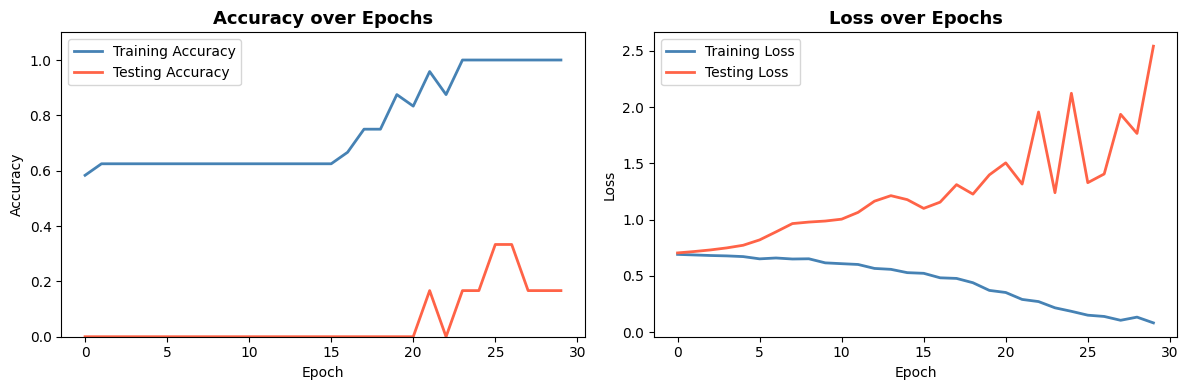

What to look for in these charts:
  Accuracy → should go UP (closer to 1.0 = better)
  Loss     → should go DOWN (closer to 0.0 = better)
  If Training is great but Testing is bad → model memorized, not learned (overfitting)


In [9]:
# ---- Draw a chart to see how training went ----
# We plot accuracy over epochs to see if the model improved

# history.history is a dictionary with keys: 'accuracy', 'val_accuracy', 'loss', 'val_loss'
# 'accuracy'     = training accuracy per epoch
# 'val_accuracy' = testing accuracy per epoch

# Create a figure with 2 side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1, 2 = 1 row, 2 columns
# figsize=(12,4) = 12 inches wide, 4 inches tall

# ---- Left chart: Accuracy ----
axes[0].plot(
    history.history['accuracy'],      # Training accuracy — one value per epoch
    label='Training Accuracy',
    color='steelblue',
    linewidth=2
)
axes[0].plot(
    history.history['val_accuracy'],  # Testing accuracy — one value per epoch
    label='Testing Accuracy',
    color='tomato',
    linewidth=2
)
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')           # X axis label
axes[0].set_ylabel('Accuracy')        # Y axis label
axes[0].legend()                      # Show the legend (which line is which)
axes[0].set_ylim(0, 1.1)             # Y axis from 0 to 1.1

# ---- Right chart: Loss ----
axes[1].plot(
    history.history['loss'],          # Training loss — should go DOWN as model learns
    label='Training Loss',
    color='steelblue',
    linewidth=2
)
axes[1].plot(
    history.history['val_loss'],      # Testing loss
    label='Testing Loss',
    color='tomato',
    linewidth=2
)
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()   # Makes sure nothing overlaps
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()

print("What to look for in these charts:")
print("  Accuracy → should go UP (closer to 1.0 = better)")
print("  Loss     → should go DOWN (closer to 0.0 = better)")
print("  If Training is great but Testing is bad → model memorized, not learned (overfitting)")

---
---
# 📌 STEP 6 — Test the Model on New Reviews

📖 Now we test our model on reviews it has **never seen before**.
We write new sentences and see if the model correctly identifies positive vs negative.

📖 **How prediction works:**
```
New review: "this film was amazing"
    ↓
Convert to numbers: [4, 12, 7, 3]
    ↓
Pad to length 20:   [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0, 4,12,7,3]
    ↓
Feed to LSTM model
    ↓
Output: 0.87  → above 0.5 → POSITIVE ✅
```

In [10]:
# ---- Function to predict sentiment of any sentence ----

def predict_sentiment(review_text):
    """
    Takes a review sentence and predicts if it is positive or negative.

    Parameters:
        review_text (str): A movie review sentence

    Returns:
        Nothing — just prints the result
    """

    # Step 1: Convert the text to lowercase
    # Our tokenizer was trained on lowercase text, so we must match that
    text = review_text.lower()

    # Step 2: Convert the text to a sequence of numbers
    # texts_to_sequences() needs a LIST of texts, even if it is just one
    # So we wrap our text in a list: [text]
    sequence = tokenizer.texts_to_sequences([text])

    # Step 3: Pad the sequence to MAX_LENGTH (same as training)
    padded = pad_sequences(sequence, maxlen=MAX_LENGTH, padding='pre')

    # Step 4: Ask the model to predict
    # model.predict() returns a 2D array like [[0.87]]
    # [0][0] gets the single number out of that array
    score = model.predict(padded, verbose=0)[0][0]

    # Step 5: Interpret the score
    # Score above 0.5 = positive, below 0.5 = negative
    if score >= 0.5:
        sentiment = 'POSITIVE 😊'
    else:
        sentiment = 'NEGATIVE 😞'

    # Confidence = how sure the model is
    # If score = 0.87, confidence = 87%
    # If score = 0.23, confidence = 1-0.23 = 0.77 = 77%
    confidence = score if score >= 0.5 else 1 - score

    # Print the result
    print(f"Review     : '{review_text}'")
    print(f"Score      : {score:.3f}  (above 0.5 = positive, below = negative)")
    print(f"Prediction : {sentiment}")
    print(f"Confidence : {confidence:.1%}")
    print()


print("✅ predict_sentiment() function is ready!")
print("Run the next cell to test it.")

✅ predict_sentiment() function is ready!
Run the next cell to test it.


In [11]:
# ---- Test on new reviews the model has never seen ----

print("=" * 58)
print("  TESTING ON NEW REVIEWS")
print("=" * 58)
print()

# These are completely NEW sentences — not in our training data
new_reviews = [
    "this was an incredible and beautiful film",      # Should be POSITIVE
    "i hated this terrible and boring movie",         # Should be NEGATIVE
    "the film was really good and very enjoyable",    # Should be POSITIVE
    "awful movie with bad acting and poor story",     # Should be NEGATIVE
    "i absolutely loved watching this amazing film",  # Should be POSITIVE
    "what a waste of time this dreadful film was",   # Should be NEGATIVE
]

for review in new_reviews:
    predict_sentiment(review)

  TESTING ON NEW REVIEWS

Review     : 'this was an incredible and beautiful film'
Score      : 0.996  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 99.6%

Review     : 'i hated this terrible and boring movie'
Score      : 0.508  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 50.8%

Review     : 'the film was really good and very enjoyable'
Score      : 0.996  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 99.6%

Review     : 'awful movie with bad acting and poor story'
Score      : 0.422  (above 0.5 = positive, below = negative)
Prediction : NEGATIVE 😞
Confidence : 57.8%

Review     : 'i absolutely loved watching this amazing film'
Score      : 0.998  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 99.8%

Review     : 'what a waste of time this dreadful film was'
Score      : 0.616  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 61.

In [12]:
# ---- Evaluate the model on the test set ----
# This gives us the final accuracy on the held-out test data

# model.evaluate() returns [loss, accuracy]
# verbose=0 means: don't print anything extra
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=" * 40)
print("  FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"  Test Accuracy : {test_accuracy:.1%}")
print(f"  Test Loss     : {test_loss:.4f}")
print()

if test_accuracy >= 0.8:
    print("  Great result! The model learned well.")
elif test_accuracy >= 0.6:
    print("  Decent result. More data would help.")
else:
    print("  Low accuracy. Our dataset is very small — this is expected.")
    print("  With 10,000+ reviews, accuracy would be much higher!")

  FINAL MODEL PERFORMANCE
  Test Accuracy : 16.7%
  Test Loss     : 2.5419

  Low accuracy. Our dataset is very small — this is expected.
  With 10,000+ reviews, accuracy would be much higher!


In [13]:
# ============================================================
# 🏋️ PRACTICE — Type your own review!
# Change the reviews in the list below and run this cell
# ============================================================

print("=" * 50)
print("  YOUR PRACTICE ZONE")
print("=" * 50)
print()

# ✏️ Change these to YOUR OWN sentences!
my_reviews = [
    "this movie was simply outstanding and beautiful",
    "i did not enjoy this film at all it was boring",
    "what a wonderful and touching story it was great",
]

for review in my_reviews:
    predict_sentiment(review)

  YOUR PRACTICE ZONE

Review     : 'this movie was simply outstanding and beautiful'
Score      : 0.995  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 99.5%

Review     : 'i did not enjoy this film at all it was boring'
Score      : 0.607  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 60.7%

Review     : 'what a wonderful and touching story it was great'
Score      : 0.992  (above 0.5 = positive, below = negative)
Prediction : POSITIVE 😊
Confidence : 99.2%



---
---
# ✅ Phase 4 — Summary

## What you learned

| Concept | What it means | Code |
|---------|--------------|------|
| **RNN** | Reads text word by word, has memory | Idea only — LSTM is better |
| **LSTM** | Smart RNN with forget/input/output gates | `LSTM(32)` |
| **Tokenizer** | Converts words → numbers | `Tokenizer()` + `fit_on_texts()` |
| **Padding** | Makes all sequences same length | `pad_sequences(..., maxlen=20)` |
| **Embedding** | Learns word vectors during training | `Embedding(vocab, dim, length)` |
| **Dropout** | Prevents memorizing — forces real learning | `Dropout(0.5)` |
| **Dense** | Final layer — outputs the prediction | `Dense(1, activation='sigmoid')` |
| **model.fit()** | Trains the model | `model.fit(X_train, y_train, epochs=30)` |
| **model.predict()** | Makes prediction on new data | `model.predict(padded)` |

---

## The 5 steps to build any LSTM model

```
1. Prepare data       → create reviews + labels
2. Tokenize           → words to numbers
3. Pad sequences      → make all same length
4. Build LSTM model   → Embedding → LSTM → Dropout → Dense
5. Train and test     → model.fit() then model.predict()
```

---

## Why our accuracy might not be perfect
We only have **30 reviews** for training.
Real NLP projects use thousands or millions of examples.
The IMDB dataset has 50,000 movie reviews — try it next!

---

## 🚀 What is next in CampusX playlist?

| Phase | Topic |
|-------|-------|
| Phase 5 | **BERT** — The most powerful NLP model. Pre-trained on the whole internet! |
| Phase 5 | **Hugging Face** — Use BERT in 5 lines of code |
| Phase 5 | **Fine-tuning** — Adapt BERT to your own task |

---
*Phase 4 complete! You built a real deep learning NLP model. That is huge! 🎉*

*Keep going with the CampusX NLP Playlist 🎓*